# Decoder analysis

Linear Decoders for **Opt mean** and **Opt variance**, then erase Opt variance with **One-step INLP** vs the **LEACE eraser**, and finally nonlinear Decoders on raw vs LEACE-erased states.


In [6]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %cd /content/kalnet
    %pip install -e .
else:
    # update for your local path
    %cd /home/jacob/kalnet


/home/jacob/kalnet


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from kalnet.decoders import (
    LinearDecoder,
    NonlinearDecoder,
    PerTimestepCenterer,
    pool_timesteps,
    select_trials,
    trial_train_validation_indices,
)
from kalnet.leace import LeaceEraser


## Data prep

Load the batch-100 dataset. **Per-timestep centering** removes the across-Trial mean of hidden states, Opt mean, and Opt variance at each timestep (means fit on train Trials only), then every Trial × timestep is pooled. Trials are split before pooling so a Trial cannot leak between training and validation.


In [27]:
dataset = torch.load(
    "saved_data/kf_allgain_100batch_dataset.pt",
    map_location="cpu",
    weights_only=False,
)

train_split = dataset["train"]
test_split = dataset["test"]
train_idx, val_idx = trial_train_validation_indices(train_split["r_hid"].shape[0])

train_trials = select_trials(train_split, train_idx)
val_trials = select_trials(train_split, val_idx)
test_trials = select_trials(test_split)

# centerer = PerTimestepCenterer().fit(
#     hidden=train_trials["r_hid"],
#     opt_mean=train_trials["mu"],
#     opt_variance=train_trials["sigma_sq"],
# )


def prepare_probe_tensors(trials):
    # hidden = centerer.transform("hidden", trials["r_hid"])
    # mean = centerer.transform("opt_mean", trials["mu"])
    # variance = centerer.transform("opt_variance", trials["sigma_sq"])
    return (
        pool_timesteps(trials["r_hid"]),
        pool_timesteps(trials["mu"]),
        pool_timesteps(trials["sigma_sq"]),
    )


X_train, mean_train, variance_train = prepare_probe_tensors(train_trials)
X_validation, mean_validation, variance_validation = prepare_probe_tensors(val_trials)
X_test, mean_test, variance_test = prepare_probe_tensors(test_trials)

print(
    f"Pooled samples: train={len(X_train):,}, "
    f"validation={len(X_validation):,}, test={len(X_test):,}"
)


Pooled samples: train=100,000, validation=25,000, test=50,000


## 1. Linear Decoders (Opt mean & Opt variance)

Fit two `LinearDecoder`s (Ridge). Report held-out test \(R^2\) and the **ambient** acute angle between their coefficient axes.


Opt mean linear test R²:     0.9996
Opt variance linear test R²: 0.9535
Ambient |cosine|:            0.0357
Ambient acute angle:         87.95°


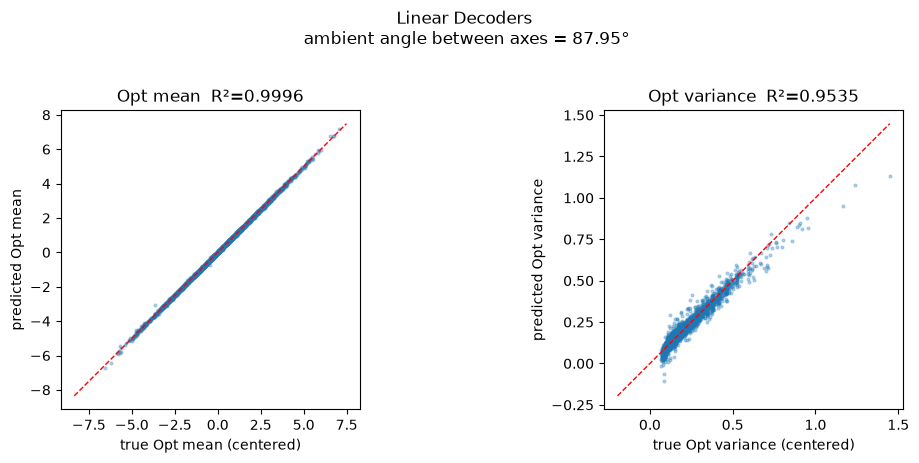

In [28]:
linear_mean = LinearDecoder().fit(X_train, mean_train)
linear_variance = LinearDecoder().fit(X_train, variance_train)

mean_pred = linear_mean.predict(X_test)
variance_pred = linear_variance.predict(X_test)
mean_true = mean_test.reshape(-1).numpy()
variance_true = variance_test.reshape(-1).numpy()

mean_linear_r2 = linear_mean.r2(X_test, mean_test)
variance_linear_r2 = linear_variance.r2(X_test, variance_test)

u_mean = linear_mean.coef_.astype(np.float64)
u_variance = linear_variance.coef_.astype(np.float64)
u_mean = u_mean / np.linalg.norm(u_mean)
u_variance = u_variance / np.linalg.norm(u_variance)

abs_cos_ambient = float(abs(np.dot(u_mean, u_variance)))
ambient_angle_deg = float(
    np.degrees(np.arccos(np.clip(abs_cos_ambient, 0.0, 1.0)))
)

print(f"Opt mean linear test R²:     {mean_linear_r2:.4f}")
print(f"Opt variance linear test R²: {variance_linear_r2:.4f}")
print(f"Ambient |cosine|:            {abs_cos_ambient:.4f}")
print(f"Ambient acute angle:         {ambient_angle_deg:.2f}°")

rng = np.random.default_rng(0)
idx = rng.choice(len(mean_true), size=min(3000, len(mean_true)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, y_true, y_pred, title, r2 in zip(
    axes,
    (mean_true, variance_true),
    (mean_pred, variance_pred),
    ("Opt mean", "Opt variance"),
    (mean_linear_r2, variance_linear_r2),
    strict=True,
):
    ax.scatter(y_true[idx], y_pred[idx], s=4, alpha=0.3)
    lims = [
        min(y_true.min(), y_pred.min()),
        max(y_true.max(), y_pred.max()),
    ]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel(f"true {title} (centered)")
    ax.set_ylabel(f"predicted {title}")
    ax.set_title(f"{title}  R²={r2:.4f}")
    ax.set_aspect("equal", adjustable="box")

fig.suptitle(
    f"Linear Decoders \n ambient angle between axes = {ambient_angle_deg:.2f}° ",
    y=1.02,
)
plt.tight_layout()
plt.show()


## 2. One-step INLP (erase Opt variance)

Orthogonally project out the Opt-variance Decoder axis \(u_\sigma\) in ambient space. Every point's coordinate along \(u_\sigma\) becomes exactly 0, so the **frozen** variance Decoder dies — but a **refit** linear variance Decoder can often recover when \(\Sigma_{XX}\) is anisotropic. Opt mean is the survival readout.

Report: (a) frozen Opt-variance \(R^2\), (b) refit Opt-variance \(R^2\), (c) refit Opt-mean \(R^2\).


metric                                     R²
frozen Opt variance (old Decoder)     -0.7702
refit Opt variance                     0.9510
refit Opt mean                         0.9996


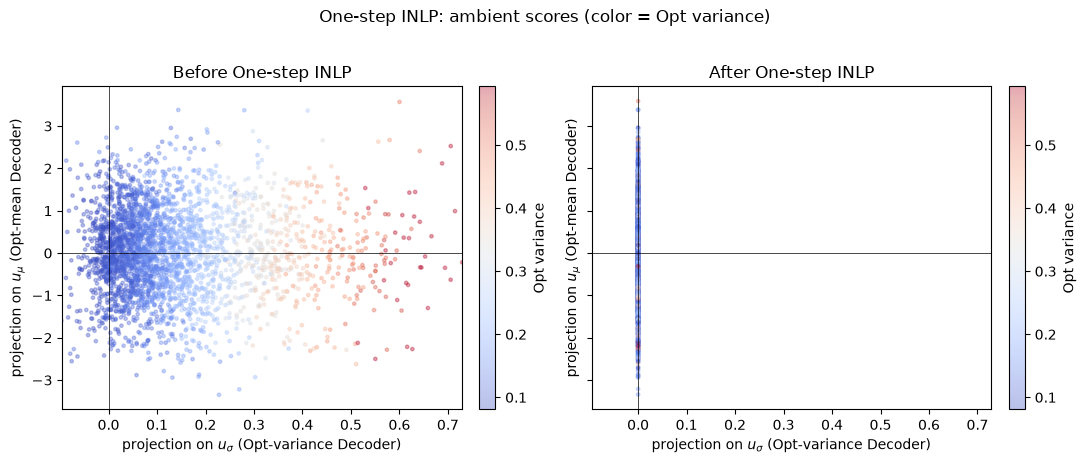

mean |x·u_σ| before=0.1483, after=3.1609e-09 (exact null)


In [29]:
def project_out(X: torch.Tensor, u: np.ndarray) -> torch.Tensor:
    """One-step INLP: X <- X - (X u) uᵀ with unit ambient axis u."""
    X_np = X.numpy().astype(np.float64)
    scores = X_np @ u
    return torch.from_numpy((X_np - np.outer(scores, u)).astype(np.float32))


X_train_inlp = project_out(X_train, u_variance)
X_validation_inlp = project_out(X_validation, u_variance)
X_test_inlp = project_out(X_test, u_variance)

frozen_variance_inlp_r2 = linear_variance.r2(X_test_inlp, variance_test)

linear_variance_inlp = LinearDecoder().fit(X_train_inlp, variance_train)
linear_mean_inlp = LinearDecoder().fit(X_train_inlp, mean_train)
refit_variance_inlp_r2 = linear_variance_inlp.r2(X_test_inlp, variance_test)
refit_mean_inlp_r2 = linear_mean_inlp.r2(X_test_inlp, mean_test)

print(f"{'metric':<36} {'R²':>8}")
print(f"{'frozen Opt variance (old Decoder)':<36} {frozen_variance_inlp_r2:8.4f}")
print(f"{'refit Opt variance':<36} {refit_variance_inlp_r2:8.4f}")
print(f"{'refit Opt mean':<36} {refit_mean_inlp_r2:8.4f}")

X_test_np = X_test.numpy().astype(np.float64)
X_test_inlp_np = X_test_inlp.numpy().astype(np.float64)
z_variance = variance_test.reshape(-1).numpy().astype(np.float64)

rng = np.random.default_rng(0)
idx = rng.choice(len(z_variance), size=min(3000, len(z_variance)), replace=False)
vmin, vmax = float(np.percentile(z_variance, 2)), float(np.percentile(z_variance, 98))

x_before = X_test_np @ u_variance
y_before = X_test_np @ u_mean
x_after = X_test_inlp_np @ u_variance
y_after = X_test_inlp_np @ u_mean
xlim = (
    float(np.percentile(x_before, 1)),
    float(np.percentile(x_before, 99)),
)
pad = 0.05 * (xlim[1] - xlim[0] + 1e-12)
xlim = (xlim[0] - pad, xlim[1] + pad)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, x, y, title in zip(
    axes,
    (x_before, x_after),
    (y_before, y_after),
    ("Before One-step INLP", "After One-step INLP"),
    strict=True,
):
    sc = ax.scatter(
        x[idx],
        y[idx],
        c=z_variance[idx],
        s=6,
        alpha=0.35,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
    )
    ax.axhline(0.0, color="black", linewidth=0.5)
    ax.axvline(0.0, color="black", linewidth=0.5)
    ax.set_xlim(xlim)
    ax.set_xlabel(r"projection on $u_\sigma$ (Opt-variance Decoder)")
    ax.set_ylabel(r"projection on $u_\mu$ (Opt-mean Decoder)")
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="Opt variance")

fig.suptitle("One-step INLP: ambient scores (color = Opt variance)", y=1.02)
plt.tight_layout()
plt.show()

print(
    f"mean |x·u_σ| before={np.abs(x_before).mean():.4f}, "
    f"after={np.abs(x_after).mean():.4e} (exact null)"
)


## 3. LEACE eraser (erase Opt variance)

Fit a **LEACE eraser** on train \((X, Z=\text{Opt variance})\). Same triad as One-step INLP: frozen variance Decoder should die; **refit** variance should stay near 0 (unlike INLP); Opt mean should survive. Ambient projection onto \(u_\sigma\) is *not* forced to exact zero — LEACE's hard null is in whitened space.

Also report the **whitened** acute angle between the two Decoder axes (using the same \(\Sigma_{XX}\) whitening LEACE uses).


metric                                     R²
frozen Opt variance (old Decoder)     -0.0008
refit Opt variance                    -0.0000
refit Opt mean                         0.9996
Whitened |cosine|:            0.0058
Whitened acute angle:         89.67°
Ambient acute angle (cell 1): 87.95°


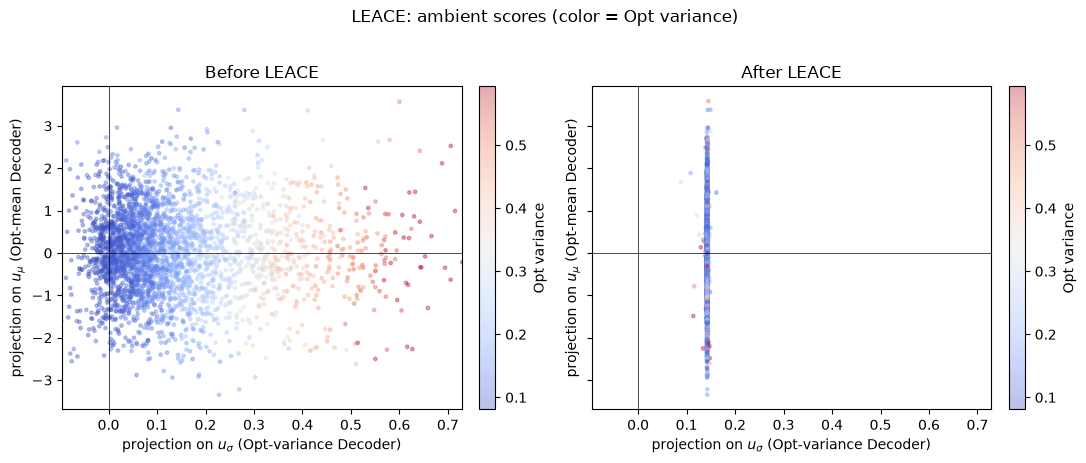

mean |x·u_σ| before=0.1483, after=0.1425 (not exact null — LEACE)


In [16]:
eraser = LeaceEraser.fit(X_train, variance_train)
X_train_leace = eraser.transform(X_train)
X_validation_leace = eraser.transform(X_validation)
X_test_leace = eraser.transform(X_test)

frozen_variance_leace_r2 = linear_variance.r2(X_test_leace, variance_test)

linear_variance_leace = LinearDecoder().fit(X_train_leace, variance_train)
linear_mean_leace = LinearDecoder().fit(X_train_leace, mean_train)
refit_variance_leace_r2 = linear_variance_leace.r2(X_test_leace, variance_test)
refit_mean_leace_r2 = linear_mean_leace.r2(X_test_leace, mean_test)

# Whitened angle between Decoder axes (dual map: Xw · (W^{-1} u) = Xc · u).
X_train_np = X_train.numpy().astype(np.float64)
n_train, _ = X_train_np.shape
mean_x = X_train_np.mean(axis=0)
Xc_train = X_train_np - mean_x
sigma_xx = (Xc_train.T @ Xc_train) / n_train
evals, evecs = np.linalg.eigh(sigma_xx)
floor = evals.max() * 1e-10
evals_clipped = np.clip(evals, floor, None)
W_inv = (evecs * np.sqrt(evals_clipped)) @ evecs.T

u_mean_w = W_inv @ u_mean
u_variance_w = W_inv @ u_variance
u_mean_w = u_mean_w / np.linalg.norm(u_mean_w)
u_variance_w = u_variance_w / np.linalg.norm(u_variance_w)
abs_cos_whitened = float(abs(np.dot(u_mean_w, u_variance_w)))
whitened_angle_deg = float(
    np.degrees(np.arccos(np.clip(abs_cos_whitened, 0.0, 1.0)))
)

print(f"{'metric':<36} {'R²':>8}")
print(f"{'frozen Opt variance (old Decoder)':<36} {frozen_variance_leace_r2:8.4f}")
print(f"{'refit Opt variance':<36} {refit_variance_leace_r2:8.4f}")
print(f"{'refit Opt mean':<36} {refit_mean_leace_r2:8.4f}")
print(f"Whitened |cosine|:            {abs_cos_whitened:.4f}")
print(f"Whitened acute angle:         {whitened_angle_deg:.2f}°")
print(f"Ambient acute angle (cell 1): {ambient_angle_deg:.2f}°")

X_test_leace_np = X_test_leace.numpy().astype(np.float64)
x_before = X_test_np @ u_variance
y_before = X_test_np @ u_mean
x_after = X_test_leace_np @ u_variance
y_after = X_test_leace_np @ u_mean

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, x, y, title in zip(
    axes,
    (x_before, x_after),
    (y_before, y_after),
    ("Before LEACE", "After LEACE"),
    strict=True,
):
    sc = ax.scatter(
        x[idx],
        y[idx],
        c=z_variance[idx],
        s=6,
        alpha=0.35,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
    )
    ax.axhline(0.0, color="black", linewidth=0.5)
    ax.axvline(0.0, color="black", linewidth=0.5)
    ax.set_xlim(xlim)
    ax.set_xlabel(r"projection on $u_\sigma$ (Opt-variance Decoder)")
    ax.set_ylabel(r"projection on $u_\mu$ (Opt-mean Decoder)")
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="Opt variance")

fig.suptitle("LEACE: ambient scores (color = Opt variance)", y=1.02)
plt.tight_layout()
plt.show()

print(
    f"mean |x·u_σ| before={np.abs(x_before).mean():.4f}, "
    f"after={np.abs(x_after).mean():.4f} (not exact null — LEACE)"
)


## 4. Nonlinear Decoders (raw vs LEACE-erased)

Train nonlinear Decoders for Opt mean and Opt variance on raw \(X\) and on LEACE-erased \(X\). Linear guarding of Opt variance does not imply the concept is gone — nonlinear probes (and Opt mean) should still work.


In [ ]:
nonlinear_mean = NonlinearDecoder(n_in=X_train.shape[1], seed=1).fit(
    X_train,
    mean_train,
    X_validation,
    mean_validation,
)
nonlinear_variance = NonlinearDecoder(n_in=X_train.shape[1], seed=2).fit(
    X_train,
    variance_train,
    X_validation,
    variance_validation,
)
nonlinear_mean_leace = NonlinearDecoder(n_in=X_train.shape[1], seed=3).fit(
    X_train_leace,
    mean_train,
    X_validation_leace,
    mean_validation,
)
nonlinear_variance_leace = NonlinearDecoder(n_in=X_train.shape[1], seed=4).fit(
    X_train_leace,
    variance_train,
    X_validation_leace,
    variance_validation,
)

rows = [
    ("Opt mean", "raw", nonlinear_mean.r2(X_test, mean_test)),
    ("Opt mean", "LEACE", nonlinear_mean_leace.r2(X_test_leace, mean_test)),
    ("Opt variance", "raw", nonlinear_variance.r2(X_test, variance_test)),
    (
        "Opt variance",
        "LEACE",
        nonlinear_variance_leace.r2(X_test_leace, variance_test),
    ),
]

print(f"{'target':<14} {'states':<8} {'nonlinear R²':>14} {'best epoch':>12}")
epoch_by_key = {
    ("Opt mean", "raw"): nonlinear_mean.best_epoch,
    ("Opt mean", "LEACE"): nonlinear_mean_leace.best_epoch,
    ("Opt variance", "raw"): nonlinear_variance.best_epoch,
    ("Opt variance", "LEACE"): nonlinear_variance_leace.best_epoch,
}
for target, states, r2 in rows:
    print(
        f"{target:<14} {states:<8} {r2:14.4f} "
        f"{epoch_by_key[(target, states)]:12d}"
    )

labels = [f"{t}\n{s}" for t, s, _ in rows]
vals = [r2 for _, _, r2 in rows]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, vals, color=["tab:blue", "tab:cyan", "tab:orange", "tab:red"])
ax.set_ylabel("test R²")
ax.set_title("Nonlinear Decoders: raw vs LEACE-erased (erase Opt variance)")
ax.set_ylim(0.0, 1.05)
ax.axhline(1.0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()
